In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis as mda

In [2]:
# Preprocess the input structures in VMD
# Select waters in the cylindrical volume defined by the min/max cartesian coorinates of the protein
# Do this for each frame, saving the coordinates of the protein and selected waters
"""
set sel [atomselect top "protein or ((resname TIP3) and (same residue as ((z >=min_Z) and (z <=max_Z) and (sqrt(sqr(x-X_CoM)+sqr(y-Y_CoM)) <= radius))))"]
set n [molinfo top get numframes]
for { set i 0 } { $i < $n } { incr i } {
  $sel frame $i
  $sel update
  $sel writepdb water_$i.pdb
}
"""

'\nset sel [atomselect top "protein or ((resname TIP3) and (same residue as ((z >=min_Z) and (z <=max_Z) and (sqrt(sqr(x-X_CoM)+sqr(y-Y_CoM)) <= radius))))"]\nset n [molinfo top get numframes]\nfor { set i 0 } { $i < $n } { incr i } {\n  $sel frame $i\n  $sel update\n  $sel writepdb water_$i.pdb\n}\n'

In [3]:
# Define a function to get the water dipole vector from a given universe object 
def GetWaterDipole(universe):
    
    # Select the Oxygen of each water molecule (used to get the residue index of the water)
    water = universe.select_atoms('resname TIP3 and name OH2')

    # Lists to hold the x, y, z compoennts of the water dipole
    x_component = [i]; y_component = []; z_component = []
    
    # For each water water molecule, select the oxygen and hydrogen atoms
    for residue in water.residues:
        OH2 = residue.atoms.indices[0]
        H1 = residue.atoms.indices[1]
        H2 = residue.atoms.indices[2]

        # Get the OH vectors
        OH2_H1 = u.select_atoms('index {}'.format(OH2)).positions - u.select_atoms('index {}'.format(H1)).positions
        OH2_H2 = u.select_atoms('index {}'.format(OH2)).positions - u.select_atoms('index {}'.format(H2)).positions
        
        # Get dipole vector (sum the two vectors)
        dip_vec = OH2_H1/np.linalg.norm(OH2_H1) + OH2_H2/np.linalg.norm(OH2_H2)
        
        # Convert to Debye - normalise, then multiply by 2.3 in the TIP3P regime
        dip_vec = 2.3*(dip_vec/np.linalg.norm(dip_vec))
        
        # append x, y, z components to respective lists
        x_component.append(dip_vec[0][0])
        y_component.append(dip_vec[0][1])
        z_component.append(dip_vec[0][2])
        
    # Return the x, y, z components of the water dipoles
    return x_component, y_component, z_component

/home/kahlan/.local/lib/python3.9/site-packages/MDAnalysis/topology/PDBParser.py:317: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "


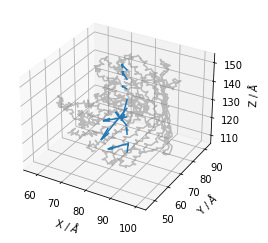

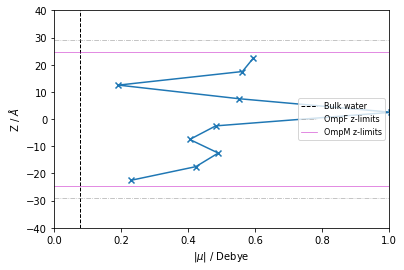

In [9]:
# Instantiate an MDA universe with the protein and waters in
# This is for a single pdb file - 
# For the average over a trajectory, loop over multiple PDB files and take the average moments across all equivalent z-slices
u = mda.Universe('filename.pdb')

# get delimiting x and y positions for the protein CA atoms to define the zone to select for water analysis
# x-radius
protein_posn = u.select_atoms('protein and name CA').positions
x_posn = []
for i in protein_posn:
    x_posn.append(i[0])
x_rad = (max(x_posn)-min(x_posn))/2

# y-radius
y_posn = []
for i in protein_posn:
    y_posn.append(i[1])
y_rad = (max(y_posn)-min(y_posn))/2

# Select whichever radius is larger
radius = round(max(x_rad, y_rad))

# Get protein CoM components
com_x = u.select_atoms('name CA').center_of_mass()[0]
com_y = u.select_atoms('name CA').center_of_mass()[1] 
com_z = u.select_atoms('name CA').center_of_mass()[2]

# x and y min and max wil be the same in every selection - CoM plus/minus the 'radius'
x_min = com_x - radius; x_max = com_x + radius
y_min = com_x - radius; y_max = com_x + radius

# Use 10 z-slices, each 5 Angstroms. This list holds the +- Z values to use in selection
# Start and end values selected to match across the two proteins (VpOmpM, EcOmpF) analysed
z_slices = np.arange(-25,26,5)

# Empty list to hold the selection strings
slice_sel = []

# Generate selection strings 
for n, i in enumerate(z_slices):
    if n < len(z_slices)-1:
        
        # Water selection - cylindrical selection in VMD, this then slices the cylinder up using cuboid selections
        sel = 'byres resname TIP3 and (prop x > {}) and (prop x < {}) and (prop y > {}) and (prop y < {}) and (prop z > {}) and (prop z < {})'.format(x_min, x_max, y_min, y_max, (com_z+i), (com_z+z_slices[n+1]))
        
        # Append the selection to the empty list
        slice_sel.append(sel)

# Empty lists to hold the average x, y, z components of the dipole moments in each z-slice   
mean_x = []; mean_y = []; mean_z = []

# Empty list to hold value of the average dipole moment
mean_magnitude = []

# For each selection string
for i in slice_sel:
    
    # Select water according to the selection string
    sel_wat = u.select_atoms(i)

    # Run the analysis
    xs,ys,zs = GetWaterDipole(sel_wat)
    
    # Take a mean of the x, y, z components across this slice
    mean_x.append(np.mean(xs))
    mean_y.append(np.mean(ys))
    mean_z.append(np.mean(zs))
    
    # Calculate magnitude
    mean_magnitude.append(np.sqrt((np.mean(xs))**2 + (np.mean(ys))**2 + (np.mean(zs))**2))

# 3D plot
# Instantiate 3D plot
ax = plt.figure().add_subplot(projection='3d')

# Plot protein backbone
ax.plot3D(u.select_atoms('backbone').positions[:,0],u.select_atoms('backbone').positions[:,1],u.select_atoms('backbone').positions[:,2],
    c='grey', alpha=0.5)

# PLOT DIPOLE MOMENT
# Set the x, y, z data - positions to draw the arrows from
# Using the CoM for x and y components, z values from the center of mass and the +- z values used earlier
x = [com_x]*len(z_slices)
y = [com_y]*len(z_slices)
z = np.array([com_z]*len(z_slices)) + np.arange(-25,26,5)
# Set the direction data for the arrows - mean x, y, z components in each slice
u_plt = mean_x; v_plt = mean_y; w_plt = mean_z
# Quiver plots for the dipole moment
# For each slice
for idx, i in enumerate(mean_x):
    # Set length of the arrow from the magnitude of the vector
    quiv_len = np.sqrt((u_plt[idx])**2 + (v_plt[idx])**2 + (w_plt[idx])**2)
    # Plot the arrow for this slice. Scale the arrow until an appropriate size
    ax.quiver(x[idx], y[idx], z[idx], u_plt[idx], v_plt[idx], w_plt[idx], length=quiv_len*20, normalize=True)
    
# Set axis labels
ax.set_xlabel('X / $\AA$'); ax.set_ylabel('Y / $\AA$'); ax.set_zlabel('Z / $\AA$')
# Show the plot
plt.show()


# 2D plot of dipole magnitude vs z
# Bulk dipole calculated to be 0.078066 
plt.axvline(0.078066, label='Bulk water',color='k',linewidth=1,linestyle='--')
# Add horizontal lines to show top and bottom of the proteins of interest
plt.axhline(-58/2,color='gray',alpha=0.6,linestyle='-.',linewidth=0.75,label='OmpF z-limits')
plt.axhline(58/2,color='gray',alpha=0.6,linestyle='-.',linewidth=0.75)
plt.axhline(-49.56/2,color='m',alpha=0.6,linestyle='-',linewidth=0.75,label='OmpM z-limits')
plt.axhline(49.56/2,color='m',alpha=0.6,linestyle='-',linewidth=0.75)

# Plot the magnitude of the average dipole moment in each z-slice
plt.plot(mean_magnitude,np.arange(-22.5,26,5))
plt.scatter(mean_magnitude,np.arange(-22.5,26,5),marker='x')

# Add labels
plt.xlabel('|$\mu$| / Debye'); plt.ylabel('Z / $\AA$')
plt.legend(fontsize=8); plt.xlim(0,1); plt.ylim(-40,40)
# Show the plot
plt.show()